## Universidad Autónoma de Aguascalientes

## Departamento: Ciencias de la Computación

## Carrera: Ingeniería en Computación Inteligente

### Curso: Aprendizaje Artificial (Machine Learning)

### Maestro: Dr. Francisco Javier Luna Rosas

### Alumno: Vanessa Reteguín

### Semestre: Enero_Junio del 2026

# Practica # 11, Regresión Lineal Simple en Python

# Paso 1: Importar las librerías necesarias

In [33]:
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Paso 2: Importamos el dataset e imprimimos las primeras filas

In [39]:
ProstateData = pd.read_csv('prostate_data.csv')
ProstateData.head()

lcavol;lweight;age;lbph;svi;lcp;gleason;pgg45;lpsa
 0 579818495;2 769459;50;-1 38629436;0;-1 38629436;6;0;-0                                             4307829 
   994252273;3 319626;58;-1 38629436;0;-1 38629436;6;0;-0                                             1625189 
   510825624;2 691243;74;-1 38629436;0;-1 38629436;7;20;-0                                            1625189 
-1 203972804;3 282789;58;-1 38629436;0;-1 38629436;6;0;-0                                             1625189 
 0 751416089;3 432373;62;-1 38629436;0;-1 38629436;6;0;0                                              3715636

# Paso 3: Nos damos cuenta de que el delimitador es ";" y que las comas en realidad deberían ser "." para indicar flotantes. Limpiamos el dataset y lo volvemos a guardar

In [57]:
new_content = ""
with open("prostate_data.csv") as dataset:
    lines = dataset.readlines()
    for i in lines:
        i = i.replace(",", ".")
        i = i.replace(";", ",")
        new_content += i
        
with open("new_prostate_data.csv", mode="w") as file:
	file.write(new_content)

ProstateData = pd.read_csv('new_prostate_data.csv')
ProstateData.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
0,-0.579818,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564


# Paso 4: Hacemos una correlación de variables para el dataset

In [60]:
ProstateData.corr()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,lpsa
lcavol,1.000000,0.280521,0.225000,0.027350,0.538845,0.675310,0.432417,0.433652,0.734460
lweight,0.280521,1.000000,0.347969,0.442264,0.155385,0.164537,0.056882,0.107354,0.433319
age,0.225000,0.347969,1.000000,0.350186,0.117658,0.127668,0.268892,0.276112,0.169593
lbph,0.027350,0.442264,0.350186,1.000000,-0.085843,-0.006999,0.077820,0.078460,0.179809
svi,0.538845,0.155385,0.117658,-0.085843,1.000000,0.673111,0.320412,0.457648,0.566218
lcp,0.675310,0.164537,0.127668,-0.006999,0.673111,1.000000,0.514830,0.631528,0.548813
gleason,0.432417,0.056882,0.268892,0.077820,0.320412,0.514830,1.000000,0.751905,0.368987
pgg45,0.433652,0.107354,0.276112,0.078460,0.457648,0.631528,0.751905,1.000000,0.422316
lpsa,0.734460,0.433319,0.169593,0.179809,0.566218,0.548813,0.368987,0.422316,1.000000


Las variables más se correlacionan son lpsa e lcavol (0.734460)

# Paso 5: Obtenemos valores importantes para la regresión lineal 

In [69]:
x = ProstateData["lcavol"]
y = ProstateData["lpsa"]
slope, intercept, r, p, std_err = stats.linregress(x, y)

# Paso 6: Creamos una función que use la pendiente (slope) y los valores de intercepción para obtener un nuevo valor. Es decir, predecir el comportamiento de la variable y respecto a x. Creamos un la lista de valores nuevos (modelo)

In [81]:
def predict(x):
  return slope * x + intercept

ProstateModel = list(map(predict, x))

In [82]:
print(ProstateModel)

[np.float64(1.0902221910485932), np.float64(0.7921115234958483), np.float64(1.1398501700454946), np.float64(0.6412552689751898), np.float64(2.047806373546239), np.float64(0.7521389965040534), np.float64(2.0375546027783957), np.float64(2.0058923598158), np.float64(0.9487244653037658), np.float64(1.66780916455194), np.float64(1.6904667980385415), np.float64(0.5383199138068153), np.float64(2.6678705102408555), np.float64(2.5697687248338967), np.float64(2.3747768513778738), np.float64(2.6158846054736227), np.float64(1.2084087260625482), np.float64(3.153452225666311), np.float64(1.1029538577103566), np.float64(1.6384450718351196), np.float64(2.332647440033402), np.float64(2.9885499428424005), np.float64(1.1154640930986404), np.float64(2.7889171695918966), np.float64(1.7844245592468755), np.float64(2.5480957877339163), np.float64(1.8761819495882484), np.float64(1.2192257776375435), np.float64(2.255589710048872), np.float64(3.2406036428148255), np.float64(1.7124324863095248), np.float64(1.638

# Paso 7: Graficamos los datos originales y la línea de predicción o tendencia

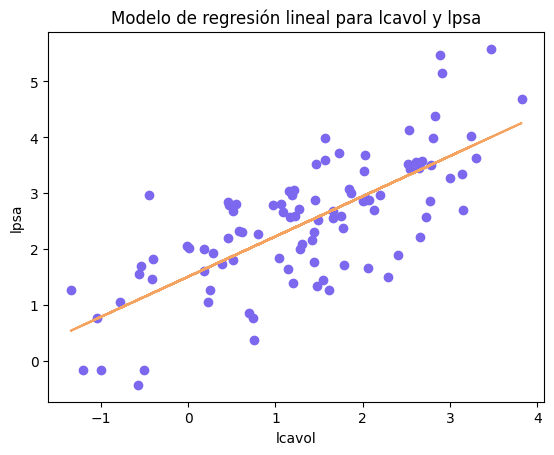

In [83]:
plt.scatter(x, y, color='mediumslateblue')
plt.plot(x, ProstateModel, color='sandybrown')
plt.title('Modelo de regresión lineal para lcavol y lpsa')
plt.xlabel('lcavol')
plt.ylabel('lpsa')
plt.show()